--- Saccadic Intelligence Report ---
Total Tokens Checked: 4096
Active High-Energy Nodes: 1212
Data Discarded (Boring): 70.41%


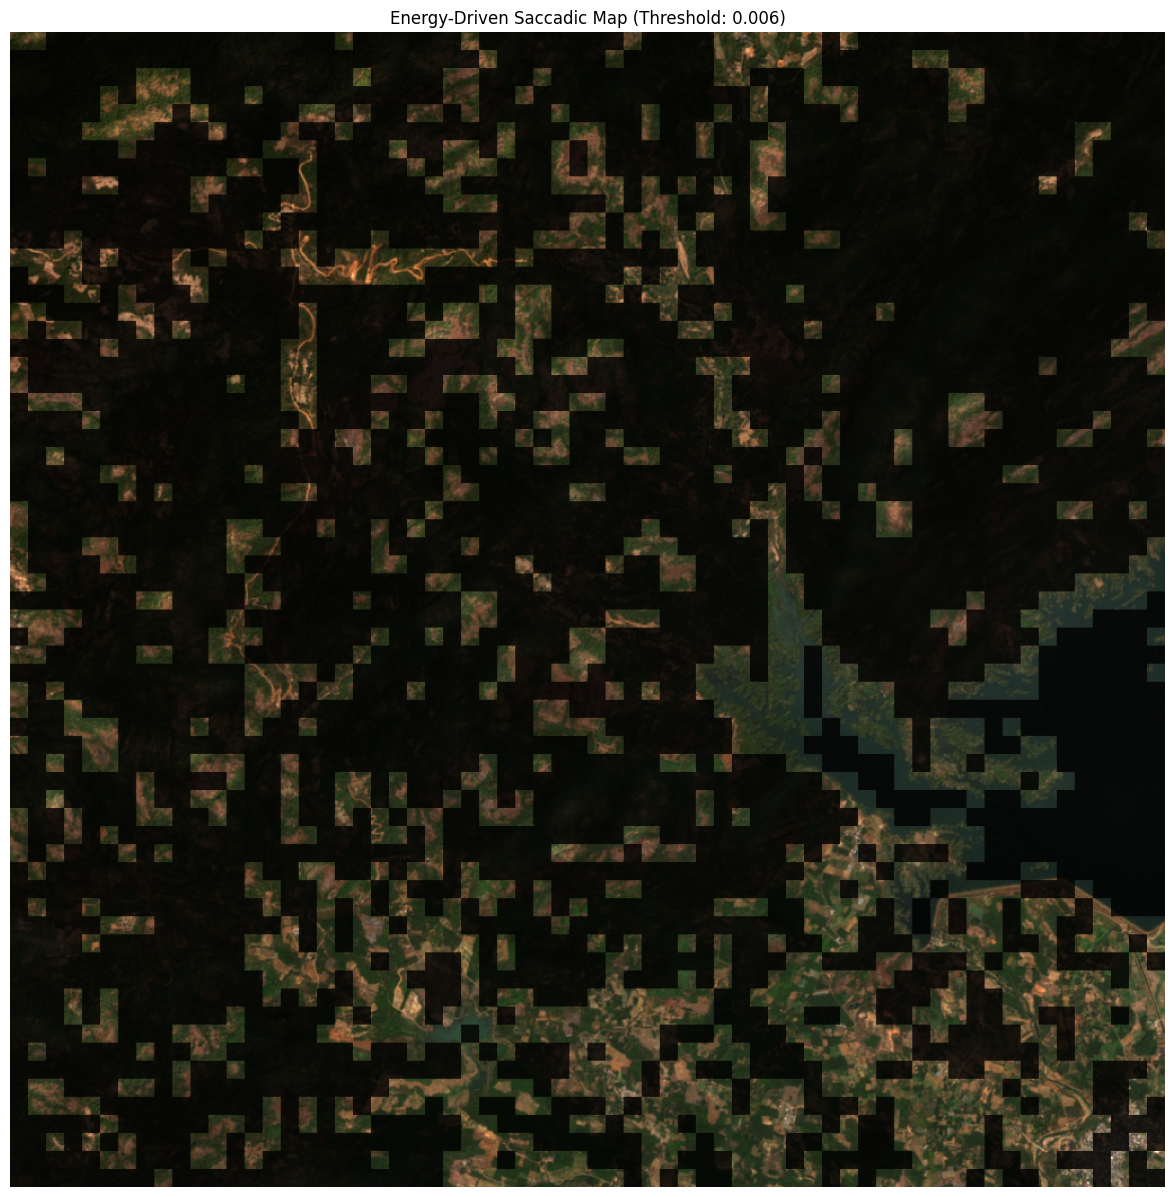

In [ ]:
import rasterio
from rasterio.windows import Window
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION (Merging Bands & TCI)
# ==========================================
# We need B04 and B08 for the math, and TCI for the human-friendly view
B04_PATH = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"
B08_PATH = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B08_10m.jp2"
TCI_PATH = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\TCI_10m.jp2"

PATCH_SIZE = 16   
THRESHOLD = 0.006 # Your updated aggressive threshold
WINDOW_SIZE = 1024 # Successfully scaled to 4K resolution!

# ==========================================
# 2. DATA ACQUISITION
# ==========================================
window = Window(0, 0, WINDOW_SIZE, WINDOW_SIZE)

with rasterio.open(B04_PATH) as red_src, \
     rasterio.open(B08_PATH) as nir_src, \
     rasterio.open(TCI_PATH) as tci_src:
    
    red = red_src.read(1, window=window).astype("float32")
    nir = nir_src.read(1, window=window).astype("float32")
    
    # Load TCI and normalize for the "Saccadic Searchlight" view
    tci = tci_src.read([1, 2, 3], window=window)
    tci = np.transpose(tci, (1, 2, 0)) / 255.0

# ==========================================
# 3. NDVI COMPUTATION (Energy Layer)
# ==========================================
np.seterr(divide='ignore', invalid='ignore')
ndvi = (nir - red) / (nir + red)
ndvi = np.nan_to_num(ndvi) # Replaces NaNs with 0

# ==========================================
# 4. SACCADIC TOKENIZATION (Claim 3 & 9)
# ==========================================
h, w = ndvi.shape
highlight_mask = np.ones((h, w)) * 0.2
active_nodes = []

num_patches_h = h // PATCH_SIZE
num_patches_w = w // PATCH_SIZE

for i in range(num_patches_h):
    for j in range(num_patches_w):
        ys, ye = i*PATCH_SIZE, (i+1)*PATCH_SIZE
        xs, xe = j*PATCH_SIZE, (j+1)*PATCH_SIZE
        
        # Calculate variance on the NDVI (Energy) layer
        patch_var = np.var(ndvi[ys:ye, xs:xe])
        
        if patch_var >= THRESHOLD:
            highlight_mask[ys:ye, xs:xe] = 1.0
            active_nodes.append((i * PATCH_SIZE + 8, j * PATCH_SIZE + 8))

# ==========================================
# 5. FUSION & REPORTING
# ==========================================
compression = 1.0 - (len(active_nodes) / (num_patches_h * num_patches_w))
saccadic_view = tci * highlight_mask[:, :, np.newaxis]

print(f"--- Saccadic Intelligence Report ---")
print(f"Total Tokens Checked: {num_patches_h * num_patches_w}")
print(f"Active High-Energy Nodes: {len(active_nodes)}")
print(f"Data Discarded (Boring): {compression:.2%}")

# Visualization
plt.figure(figsize=(15, 15))
plt.imshow(saccadic_view)
plt.title(f"Energy-Driven Saccadic Map (Threshold: {THRESHOLD})")
plt.axis('off')
plt.show()